In [12]:
import pandas as pd

rfm = pd.read_csv("../Data/Cleaned data/rfm_base.csv")

In [13]:
rfm.head()

,customer_id,last_purchase,frequency,monetary
0,C078,2023-11-02,9,44597.0
1,C095,2023-12-10,11,45692.0
2,C096,2023-12-02,3,12240.0
3,C011,2023-12-17,7,15042.0
4,C046,2023-12-05,14,29150.0


In [14]:
# Convert last_purchase to datetime
rfm['last_purchase'] = pd.to_datetime(rfm['last_purchase'])

In [15]:
# Calculate Recency (Defining reference date)

reference_date = rfm['last_purchase'].max()

rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

In [16]:
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,C078,2023-11-02,9,44597.0,57
1,C095,2023-12-10,11,45692.0,19
2,C096,2023-12-02,3,12240.0,27
3,C011,2023-12-17,7,15042.0,12
4,C046,2023-12-05,14,29150.0,24


In [17]:
# Create R, F, M Scores (1 to 5 scale)
# Recency (lower is better → reverse scoring)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])

In [18]:
# Frequency (higher is better)
rfm['F_score'] = pd.qcut(rfm['frequency'], 5, labels=[1,2,3,4,5])

In [22]:

# Monetary (higher is better)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

In [23]:
# Convert Scores to Integer

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [24]:
# Create Combined RFM Score
rfm['RFM_segment'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [25]:
# Create Customer Segmentation Logic
def segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] == 1:
        return 'Lost Customers'
    else:
        return 'Potential'

rfm['Customer_Type'] = rfm.apply(segment, axis=1)

In [26]:
# Check Segment Distribution
rfm['Customer_Type'].value_counts()

Customer_Type
Potential          33
Loyal Customers    27
At Risk            17
Lost Customers     12
Champions          11
Name: count, dtype: int64

In [27]:
rfm.head()

,customer_id,last_purchase,frequency,monetary,recency,R_score,F_score,M_score,RFM_segment,Customer_Type
0,C078,2023-11-02,9,44597.0,57,1,2,5,125,Lost Customers
1,C095,2023-12-10,11,45692.0,19,4,3,5,435,Loyal Customers
2,C096,2023-12-02,3,12240.0,27,4,1,1,411,Potential
3,C011,2023-12-17,7,15042.0,12,5,1,1,511,Potential
4,C046,2023-12-05,14,29150.0,24,4,5,2,452,Loyal Customers


In [28]:
# average spend per segment

rfm.groupby('Customer_Type')['monetary'].mean()

Customer_Type
At Risk            42218.470588
Champions          51498.727273
Lost Customers     26882.250000
Loyal Customers    36903.222222
Potential          27812.424242
Name: monetary, dtype: float64

In [29]:
# Revenue Contribution per Segment
rfm.groupby('Customer_Type')['monetary'].sum().sort_values(ascending=False)

Customer_Type
Loyal Customers    996387.0
Potential          917810.0
At Risk            717714.0
Champions          566486.0
Lost Customers     322587.0
Name: monetary, dtype: float64

In [30]:
# Percentage Contribution
segment_revenue = rfm.groupby('Customer_Type')['monetary'].sum()
(segment_revenue / segment_revenue.sum()) * 100

Customer_Type
At Risk            20.383904
Champions          16.088855
Lost Customers      9.161842
Loyal Customers    28.298538
Potential          26.066861
Name: monetary, dtype: float64

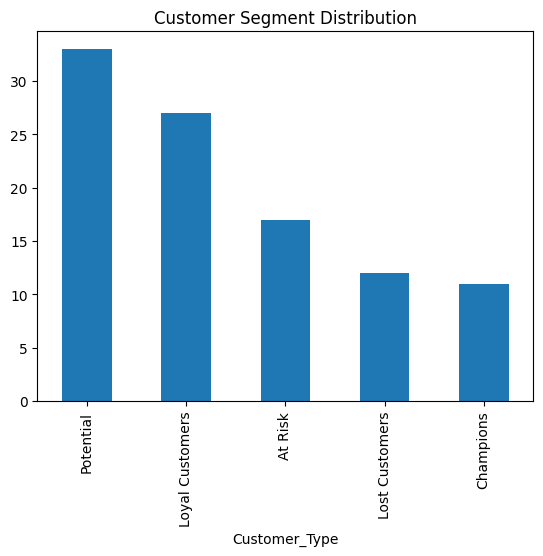

In [31]:
# Visualization 

import matplotlib.pyplot as plt

rfm['Customer_Type'].value_counts().plot(kind='bar')
plt.title("Customer Segment Distribution")
plt.show()

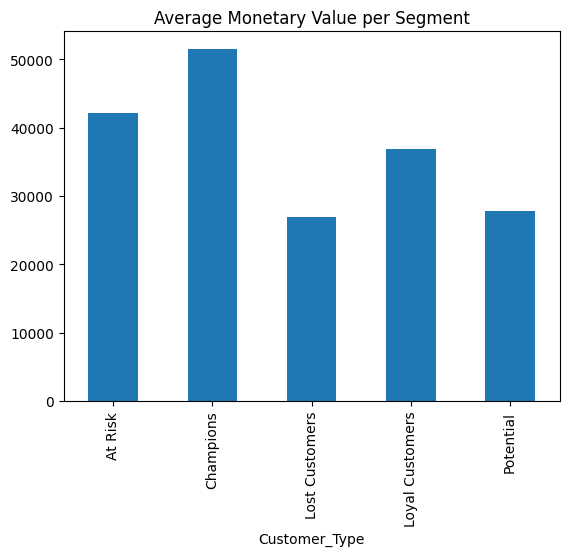

In [32]:
rfm.groupby('Customer_Type')['monetary'].mean().plot(kind='bar')
plt.title("Average Monetary Value per Segment")
plt.show()

In [33]:
# Final Processed File

rfm.to_csv("../Data/Cleaned data/rfm_final.csv", index=False)

In [35]:
segment_summary = rfm.groupby('Customer_Type').agg({
    'customer_id':'count',
    'monetary':'sum'
}).reset_index()

segment_summary

,Customer_Type,customer_id,monetary
0,At Risk,17,717714.0
1,Champions,11,566486.0
2,Lost Customers,12,322587.0
3,Loyal Customers,27,996387.0
4,Potential,33,917810.0
